In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, log_loss, roc_auc_score, accuracy_score
from sklearn.calibration import CalibratedClassifierCV
import joblib
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

### Train Model

In [2]:
# Load datasets
train_df = pd.read_csv("train_dataset.csv")
val_df = pd.read_csv("val_dataset.csv")

In [3]:
# Label
target = 'complete'

# Features (all columns in your CSV except target and IDs)
id_cols = ['game_id', 'play_id']
feature_cols = [c for c in train_df.columns if c not in [target] + id_cols]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

for col in ['route_group', 'route_of_targeted_receiver']:
    X_train[col] = X_train[col].astype('category').cat.codes
    X_val[col] = X_val[col].astype('category').cat.codes

/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_92340/1613854857.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category').cat.codes
/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_92340/1613854857.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col] = X_val[col].astype('category').cat.codes
/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_92340/1613854857.py:15: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [4]:
# Fit XGBoost classifier with best Parameters
xgb_model = XGBClassifier(
    n_estimators=500,         # Number of boosting rounds / trees
    max_depth=6,              # Max depth of fitted trees
    learning_rate=0.05,       # Small Learning Rate
    subsample=0.8,            # Percentage of rows used for each round
    colsample_bytree=0.8,     # Percentage of features used for each round
    reg_alpha=1.0,            # L1 regularization
    reg_lambda=1.0,           # L2 regularization
    eval_metric='logloss',    # Evaluation Metric Used for Probability
    enable_categorical=True,  # Enable Handing of Categorical Features
    random_state=42,
    tree_method="hist",
    early_stopping_rounds=50
)

# Fit the model
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [5]:
# Save Model
joblib.dump(xgb_model, "completion_prob_model_xgb.pkl")

['completion_prob_model_xgb.pkl']

### Basic Model Analysis

In [6]:
# Predict probabilities
y_val_pred_proba = xgb_model.predict_proba(X_val)[:, 1]  # probability of completion

# Optional: predict 0/1
y_val_pred = xgb_model.predict(X_val)

# Metrics
auc = roc_auc_score(y_val, y_val_pred_proba)
accuracy = accuracy_score(y_val, y_val_pred)
logloss = log_loss(y_val, y_val_pred_proba)

# How well model distinguishes between complete vs. incomplete
print(f"Validation AUC: {auc:.4f}")

# Percentage of plays correctly classified (>0.5 complete, else incomplete)
print(f"Validation Accuracy: {accuracy:.4f}") 

# How close probabilities are to complete result
print(f"Validation Log Loss: {logloss:.4f}")

Validation AUC: 0.7881
Validation Accuracy: 0.7217
Validation Log Loss: 0.5346


### Feature Importance

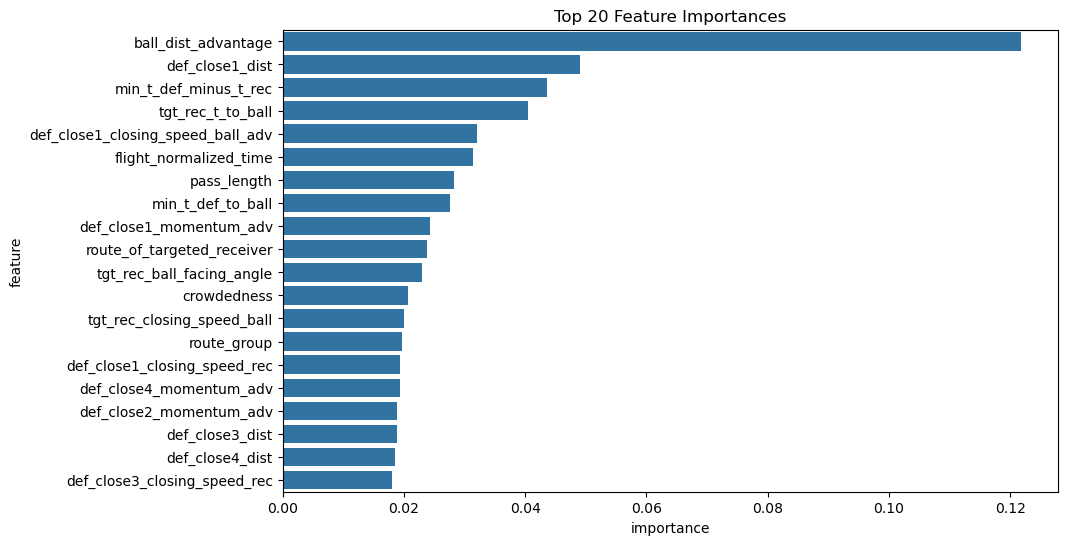

In [7]:
# Get feature importance
importance = xgb_model.feature_importances_
fi_df = pd.DataFrame({'feature': feature_cols, 'importance': importance})
fi_df = fi_df.sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10,6))
sns.barplot(data=fi_df.head(20), x='importance', y='feature')
plt.title("Top 20 Feature Importances")
plt.show()

### Augment Data with Model Results

In [ ]:
# Feature List
cat_cols = ['route_group', 'route_of_targeted_receiver']

num_cols = [
    'flight_normalized_time', 'pass_length',
    'def_close1_dist', 'def_close2_dist', 'def_close3_dist', 'def_close4_dist',
    'tgt_rec_closing_speed_ball', 'def_close1_closing_speed_ball', 'def_close2_closing_speed_ball',
    'def_close3_closing_speed_ball', 'def_close4_closing_speed_ball', 'def_close1_closing_speed_ball_adv',
    'def_close2_closing_speed_ball_adv', 'def_close3_closing_speed_ball_adv', 'def_close4_closing_speed_ball_adv',
    'def_close1_momentum_adv', 'def_close2_momentum_adv', 'def_close3_momentum_adv', 'def_close4_momentum_adv',
    'def_close1_closing_speed_rec', 'def_close2_closing_speed_rec', 'def_close3_closing_speed_rec', 'def_close4_closing_speed_rec',
    'mean_separation_closest_3_defs', 'min_ball_dist_all_def', 'ball_dist_advantage',
    'def_close1_angle_rec_deg', 'def_close2_angle_rec_deg', 'def_close3_angle_rec_deg', 'def_close4_angle_rec_deg',
    'def_close1_angle_ball_deg', 'def_close2_angle_ball_deg', 'def_close3_angle_ball_deg', 'def_close4_angle_ball_deg',
    'tgt_rec_t_to_ball', 'min_t_def_to_ball', 'min_t_def_minus_t_rec', 'tgt_rec_ball_facing_angle',
    'tgt_rec_sideline_dist', 'tgt_rec_turn_angle_smoothed', 'crowdedness', 'tgt_rec_a_toward_ball',
    'closest_2_def_angle_diff'
]

model_cols = cat_cols + num_cols

In [ ]:
data_adv = pd.read_csv("data_adv.csv")

In [ ]:
def augment_completion_prob(df, model_cols, xgb_model):
    df_aug = df.copy()

    df_aug['completion_prob'] = np.nan

    after_release_mask = df['to_release'] == 'after'
    frames_after_release = df_aug[after_release_mask]

    for (gid, pid), play_data in frames_after_release.groupby(['game_id', 'play_id']):
        play_data = play_data.sort_values('frame_global', ascending=True)

        X_play = play_data[model_cols].copy()

        for col in ['route_group', 'route_of_targeted_receiver']:
            if col in X_play.columns:
                X_play[col] = X_play[col].astype('category').cat.codes

        # Predict probabilities
        probs = xgb_model.predict_proba(X_play)[:, 1]

        # Assign back to the dataframe
        df_aug.loc[play_data.index, 'completion_prob'] = probs

        # Calculate Area Under Curve (AUC) slices relative to first frame of play
        baseline_prob = probs[0]
        width = 1 / len(probs)
        height = probs - baseline_prob
        auc_slices = width * height
        df_aug.loc[play_data.index, 'auc_slice'] = auc_slices

    return df_aug

In [ ]:
data_with_probs = augment_completion_prob(data_adv, model_cols, xgb_model)

In [ ]:
data_with_probs.to_csv("data_with_probs.csv", index=False)